In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sacc

## Comparison with CLCosmoSim Data

This notebook compares our results with those of Payerne et al. (2025), presented in the paper  
[Weak lensing mass-richness relation of redMaPPer clusters in LSST DESC DC2 simulations](https://www.aanda.org/articles/aa/abs/2025/08/aa54107-25/aa54107-25.html).

### CLCosmoSim Data

<Figure size 700x400 with 0 Axes>

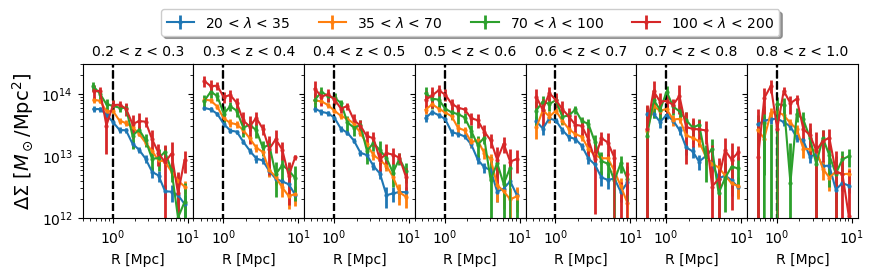

In [2]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
sys.path.append('/sps/lsst/users/ebarroso/CLCosmo_Sim')
import _redshift_richness_bins as analysis

plt.figure(figsize=(7,4))
index = 12
fmt = ['-', '--', '.']
suff = '_full_coverage'
path_to_data = '/sps/lsst/users/ebarroso/CLCosmo_Sim_database/data/'
data = np.load(path_to_data + f'stacked_esd_profiles_redmapper_true{suff}.pkl', allow_pickle=True)
profiles = data['stacked profile']
covariances = data['stacked covariance']
Z_bin = analysis.Z_bin
Obs_bin = analysis.Obs_bin
n_z_bin = len(Z_bin) 
n_m_bin = len(Obs_bin) 
fig, axs = plt.subplots(1,len(Z_bin), figsize = (10,2))
fig.subplots_adjust(wspace=0, hspace=0)
for i, z_bin in enumerate(Z_bin):
    for j, m_bin in enumerate(Obs_bin):

            label_z =   f'{z_bin[0]:.1f} < z < {z_bin[1]:.1f}'
            label_M = f'{m_bin[0]:.0f} < ' + r'$\lambda$' +f' < {m_bin[1]:.0f}'
            mask_z = (profiles['z_mean'] > z_bin[0])*(profiles['z_mean'] < z_bin[1])
            mask_m = (profiles['obs_mean'] > m_bin[0])*(profiles['obs_mean'] < m_bin[1])
            index = np.arange(len(profiles))
            index_cut = index[mask_m * mask_z]
            f_cut = profiles[index_cut]
            cov = np.array(covariances['cov_t'][index_cut])
            err = cov.T.diagonal()**.5
            axs[i].errorbar(f_cut['radius'][0], f_cut['gt'][0] , err[0],
                            marker = 'o',fmt = '-', elinewidth = 2,  markersize = 2, markerfacecolor = None, label = label_M)
            axs[i].set_ylim(1e12, 3e14)
            axs[i].set_xlim(0.4, 12)
            axs[i].set_xscale('log')
            axs[i].set_yscale('log')
            axs[i].vlines(1, 0, 1e19, ls='--', color='k')
            axs[i].tick_params(axis='both', which = 'major', labelsize= 10)
            #axs[0].legend(frameon = False, loc = 'upper right', fontsize = 10)
            axs[i].set_xlabel('R [Mpc]', fontsize = 10)
            axs[i].set_title(label_z, fontsize = 10)
            axs[0].set_ylabel(r'$\Delta\Sigma\ [M_\odot/$Mpc$^2]$', fontsize=14)
        #except: a=1
        
plt.legend(loc='upper center', bbox_to_anchor=(-2.5, 1.4),
          ncol=4, fancybox=True, shadow=True)

for ax in fig.get_axes():
    ax.label_outer()
#plt.savefig('../fig/stacked_redmapper_profiles.png', bbox_inches='tight', dpi=100)

## Comparison to CLCosmoSim data
First for 10mpc to see the whole vector and then for the interval we use for cosmology, R = [1.1, 3.7] MPC

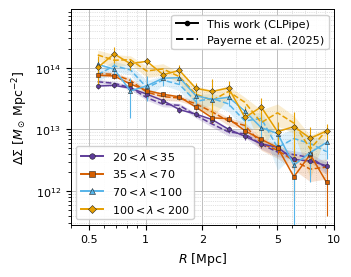

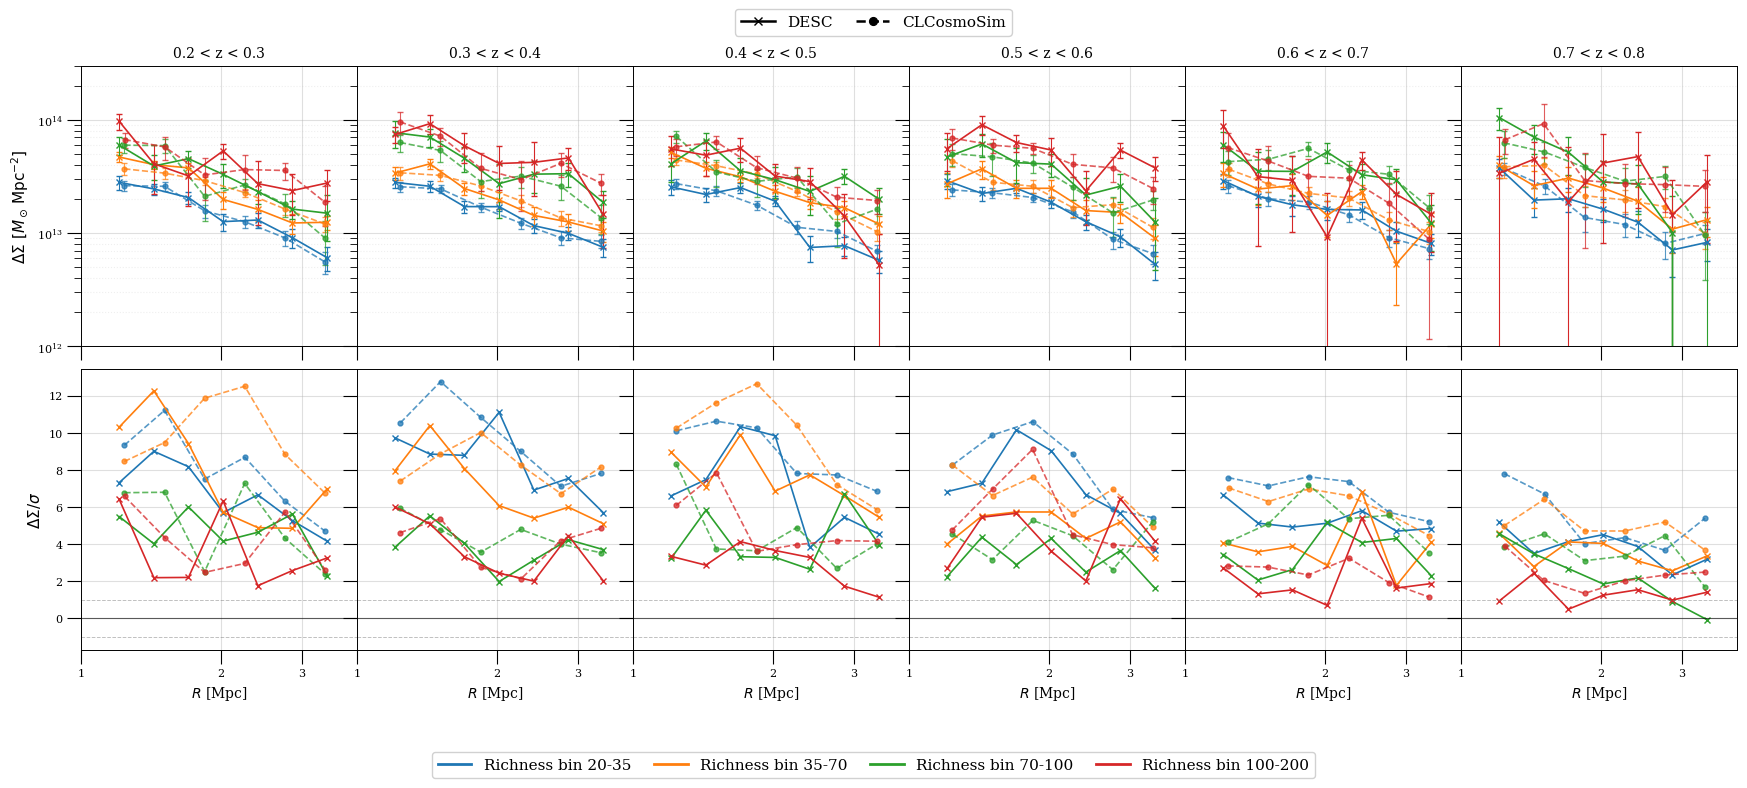

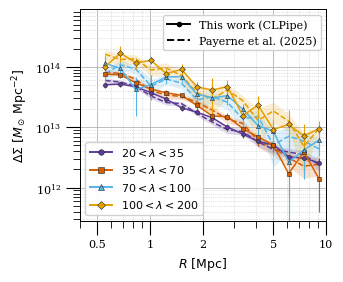

In [6]:
%matplotlib inline
import sys
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
sys.path.append("../../clpipe/utils")
from cosmosis_mcmc_plots import (
    use_paper_style, add_grid, richness_label,
    RICHNESS_COLORS, RICHNESS_MARKERS, COLUMN_WIDTH,
)
use_paper_style()

rich_bin_label = ["20-35", "35-70", "70-100", "100-200"]
richs = [20, 35, 70, 100, 200]
# Load data
sacc_file = "/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/outputs-full-10mpc-2026/cluster_sacc_catalog.sacc"
t1 = sacc.Sacc.load_fits(sacc_file)

z_bin_index = 1  # 0.3 < z < 0.4
zbin = f"bin_z_{z_bin_index}"
z_bin = Z_bin[z_bin_index]

fig, ax = plt.subplots(figsize=(COLUMN_WIDTH, 2.8))

for i_rich, label in enumerate(rich_bin_label):
    rich_bin = f"bin_rich_{i_rich}"
    color = RICHNESS_COLORS[i_rich]

    radius_vals, data_true, data_err = [], [], []

    for i in range(15):
        radius_key = f"radius_{i}"
        trac = ("cosmodc2_redmapper", rich_bin, zbin, radius_key)

        radius_vals.append(t1.tracers[radius_key].center)

        val = t1.get_data_points(
            sacc.data_types.standard_types.cluster_delta_sigma, trac
        )[0].value
        data_true.append(val)

        idx = t1.indices(
            sacc.data_types.standard_types.cluster_delta_sigma, trac
        )
        data_err.append(np.sqrt(t1.covariance.covmat[idx][:, idx][0, 0]))

    # --- This work (TXPipe data vector used by CLPipe): markers, solid line ---
    ax.errorbar(
        radius_vals,
        data_true,
        yerr=data_err,
        marker=RICHNESS_MARKERS[i_rich],
        markersize=3,
        markeredgecolor="0.15",
        markeredgewidth=0.4,
        linestyle="-",
        linewidth=1.1,
        elinewidth=0.8,
        color=color,
        zorder=4,
    )

    # --- Payerne et al. (2025): dashed line, shaded 1 sigma band ---
    m_bin = Obs_bin[i_rich]

    mask = (
        (profiles["z_mean"] > z_bin[0]) & (profiles["z_mean"] < z_bin[1]) &
        (profiles["obs_mean"] > m_bin[0]) & (profiles["obs_mean"] < m_bin[1])
    )

    idx = np.where(mask)[0]

    if len(idx) > 0:
        f = profiles[idx]
        cov = np.array(covariances["cov_t"][idx])
        err = np.sqrt(cov.T.diagonal())

        ax.plot(
            f["radius"][0],
            f["gt"][0],
            "--",
            color=color,
            linewidth=1.1,
            zorder=3,
        )

        ax.fill_between(
            f["radius"][0],
            f["gt"][0] - err[0],
            f["gt"][0] + err[0],
            color=color,
            alpha=0.18,
            linewidth=0,
            zorder=2,
        )


ax.set_xlabel(r"$R\ [\mathrm{Mpc}]$")
ax.set_ylabel(r"$\Delta\Sigma\ [M_\odot\,\mathrm{Mpc}^{-2}]$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.4, 10)
# headroom above the profiles for the line-style legend
y_low, y_high = ax.get_ylim()
ax.set_ylim(y_low, 3 * y_high)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.5, 1, 2, 5, 10]))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
add_grid(ax)


rich_handles = [
    Line2D(
        [0], [0],
        color=RICHNESS_COLORS[i],
        marker=RICHNESS_MARKERS[i],
        markeredgecolor="0.15",
        markeredgewidth=0.4,
        linestyle="-",
        label=richness_label(richs[i], richs[i + 1]),
    )
    for i in range(len(rich_bin_label))
]

legend1 = ax.legend(
    handles=rich_handles,
    loc="lower left",
)

ax.add_artist(legend1)

style_handles = [
    Line2D([0], [0], color="black", linestyle="-", marker="o", markersize=3,
           label="This work (CLPipe)"),
    Line2D([0], [0], color="black", linestyle="--", label="Payerne et al. (2025)"),
]

ax.legend(
    handles=style_handles,
    loc="upper right",
)

fig.savefig("./figures/10mpc_clpipeline_vs_clcosmo.pdf", bbox_inches="tight", pad_inches=0.03)
plt.show()


## Cosmological Data Vector

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import sacc

# ─────────────────────────────────────────
# Load SACC catalog
# ─────────────────────────────────────────
t1 = sacc.Sacc.load_fits(
    "/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/"
    "cosmodc2/outputs-full-2026/cluster_sacc_catalog.sacc"
)

cmap     = plt.get_cmap('tab10')
n_radius = 7

Z_bin_cosmo = [
    [0.2,0.3],[0.3,0.4],[0.4,0.5],
    [0.5,0.6],[0.6,0.7],[0.7,0.8]
]

n_col = len(Z_bin_cosmo)

# ─────────────────────────────────────────
# Tick helper (IMPORTANT FIX)
# ─────────────────────────────────────────
def apply_clean_log_xaxis(ax, ticks=(1, 2, 3)):
    ax.set_xscale('log')

    # IMPORTANT: avoid including upper bound (4 causes overlap)
    ax.set_xlim(1.0, 3.95)

    ax.xaxis.set_major_locator(mticker.FixedLocator(ticks))
    ax.xaxis.set_minor_locator(mticker.NullLocator())

    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:g}")
    )

# ─────────────────────────────────────────
# Figure layout (shared x FIX)
# ─────────────────────────────────────────
fig = plt.figure(figsize=(18, 8))

gs = GridSpec(
    2, n_col,
    figure=fig,
    hspace=0.08,
    wspace=0.0,
    left=0.06, right=0.98,
    top=0.91,
    bottom=0.18
)

axs_top = []
axs_bot = []

for i in range(n_col):
    ax_top = fig.add_subplot(gs[0, i])
    ax_bot = fig.add_subplot(gs[1, i], sharex=ax_top)

    axs_top.append(ax_top)
    axs_bot.append(ax_bot)

# share y within rows
for axes in [axs_top, axs_bot]:
    for ax in axes[1:]:
        ax.sharey(axes[0])

# ─────────────────────────────────────────
# Helper: DESC data
# ─────────────────────────────────────────
def get_desc_point(t, rich_bin, zbin, radius_key):
    trac = ('cosmodc2_redmapper', rich_bin, zbin, radius_key)
    pts = t.get_data_points(
        sacc.data_types.standard_types.cluster_delta_sigma, trac
    )
    if len(pts) == 0:
        return None

    idx = t.indices(
        sacc.data_types.standard_types.cluster_delta_sigma, trac
    )
    if len(idx) == 0:
        return None

    value = pts[0].value
    error = np.sqrt(t.covariance.covmat[idx][:, idx][0, 0])
    radius = t.tracers[radius_key].center

    return radius, value, error

# ─────────────────────────────────────────
# Main loop
# ─────────────────────────────────────────
for i, z_bin in enumerate(Z_bin_cosmo):

    ax_ds  = axs_top[i]
    ax_snr = axs_bot[i]

    desc_bin_exists = (i < len(Z_bin))

    for j, m_bin in enumerate(Obs_bin):

        rich_bin = f'bin_rich_{j}'
        zbin     = f'bin_z_{i}'
        color    = cmap(j)

        radius_vals = []
        data_true = []
        data_true_error = []

        # ─────────────── ΔΣ DESC ───────────────
        if desc_bin_exists:
            for k in range(n_radius):
                res = get_desc_point(t1, rich_bin, zbin, f'radius_{k}')
                if res is None:
                    continue
                r, v, e = res
                radius_vals.append(r)
                data_true.append(v)
                data_true_error.append(e)

            if radius_vals:
                ax_ds.errorbar(
                    radius_vals, data_true, yerr=data_true_error,
                    color=color, linestyle='-', marker='x',
                    markersize=4, elinewidth=0.8, capsize=2, lw=1.2
                )

        # ─────────────── CLCosmoSim ΔΣ ───────────────
        mask_z = (profiles['z_mean'] > z_bin[0]) & (profiles['z_mean'] < z_bin[1])
        mask_m = (profiles['obs_mean'] > m_bin[0]) & (profiles['obs_mean'] < m_bin[1])
        index_cut = np.where(mask_z & mask_m)[0]

        if len(index_cut) > 0:
            f_cut = profiles[index_cut]

            r_cl  = f_cut['radius'][0]
            gt_cl = f_cut['gt'][0]

            cov    = np.array(covariances['cov_t'][index_cut])[0]
            err_cl = np.sqrt(np.diag(cov))

            if radius_vals:
                mask_r = (r_cl >= min(radius_vals)) & (r_cl <= max(radius_vals))
            else:
                mask_r = np.ones(len(r_cl), dtype=bool)

            if np.any(mask_r):
                ax_ds.errorbar(
                    r_cl[mask_r], gt_cl[mask_r], yerr=err_cl[mask_r],
                    color=color, linestyle='--', marker='o',
                    markersize=3.5, elinewidth=0.8, capsize=2,
                    alpha=0.75, lw=1.2
                )

        # ─────────────── SNR ───────────────
        sn_radius, sn_desc = [], []

        if desc_bin_exists:
            for k in range(n_radius):
                res = get_desc_point(t1, rich_bin, zbin, f'radius_{k}')
                if res is None:
                    continue
                r, v, e = res
                sn_radius.append(r)
                sn_desc.append(v / e)

            if sn_radius:
                ax_snr.plot(
                    sn_radius, sn_desc,
                    color=color, linestyle='-', marker='x',
                    markersize=4, lw=1.2
                )

        if len(index_cut) > 0 and np.any(mask_r):
            sn_cl = gt_cl[mask_r] / err_cl[mask_r]
            ax_snr.plot(
                r_cl[mask_r], sn_cl,
                color=color, linestyle='--', marker='o',
                markersize=3.5, alpha=0.75, lw=1.2
            )

    # ─────────────────────────────────────────
    # ΔΣ axis styling
    # ─────────────────────────────────────────
    ax_ds.set_yscale('log')
    #ax_ds.set_xlim(1.0, 4.0)
    ax_ds.set_ylim(1e12, 3e14)

    apply_clean_log_xaxis(ax_ds)

    ax_ds.grid(True, which='major', alpha=0.4)
    ax_ds.grid(True, which='minor', alpha=0.2, ls=':')

    ax_ds.set_title(f'{z_bin[0]:.1f} < z < {z_bin[1]:.1f}', fontsize=10)

    if i == 0:
        ax_ds.set_ylabel(r'$\Delta\Sigma\ [M_\odot\,\mathrm{Mpc}^{-2}]$', fontsize=11)
    else:
        plt.setp(ax_ds.get_yticklabels(), visible=False)

    ax_ds.tick_params(labelbottom=False)

    # ─────────────────────────────────────────
    # SNR axis styling
    # ─────────────────────────────────────────
    #ax_snr.set_xlim(1.0, 4.0)

    apply_clean_log_xaxis(ax_snr)

    ax_snr.axhline(0,  color='k', lw=0.8, alpha=0.6)
    ax_snr.axhline(1,  color='gray', lw=0.7, ls='--', alpha=0.5)
    ax_snr.axhline(-1, color='gray', lw=0.7, ls='--', alpha=0.5)

    ax_snr.grid(True, which='major', alpha=0.4)
    ax_snr.grid(True, which='minor', alpha=0.2, ls=':')

    ax_snr.set_xlabel(r'$R$ [Mpc]', fontsize=10)

    if i == 0:
        ax_snr.set_ylabel(r'$\Delta\Sigma/\sigma$', fontsize=11)
    else:
        plt.setp(ax_snr.get_yticklabels(), visible=False)

# ─────────────────────────────────────────
# Legends
# ─────────────────────────────────────────
style_handles = [
    Line2D([0],[0], color='k', lw=1.8, ls='-',  marker='x', label='DESC'),
    Line2D([0],[0], color='k', lw=1.8, ls='--', marker='o', label='CLCosmoSim'),
]

color_handles = [
    Line2D([0],[0], color=cmap(j), lw=2,
           label=f'Richness bin {binj}')
    for j, binj in enumerate(rich_bin_label)
]

fig.legend(handles=style_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.99), ncol=2,    frameon=True,
    fontsize=11,
    markerscale=1.4,
    handlelength=2.2,
    columnspacing=1.5,
    labelspacing=0.8,
    framealpha=0.9,
    edgecolor='0.8'
)

# fig.legend(handles=color_handles, loc='lower center',
#            bbox_to_anchor=(0.5, 0.01),
#            ncol=len(Obs_bin))
fig.legend(
    handles=color_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    ncol=len(Obs_bin),
    frameon=True,
    fontsize=11,
    markerscale=1.4,
    handlelength=2.2,
    columnspacing=1.5,
    labelspacing=0.8,
    framealpha=0.9,
    edgecolor='0.8'
)
# plt.savefig("./figures/delta_sigma_snr_clean.pdf", dpi=200, bbox_inches='tight')
plt.show()

## Mean Number of galaxies

In [5]:
import h5py
import numpy as np

file = "/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/outputs-full-2026/shear_tomography_catalog.hdf5"

area_arcmin2 = 440 * 3600

with h5py.File(file, "r") as f:
    print("Available counts fields:", list(f["counts"].keys()))

    # 1D effective number of galaxies
    N_eff = np.array(f["counts"]["N_eff"])

    # 1D raw counts
    N_raw = np.array(f["counts"]["counts"])

# total effective density
n_eff_global = np.sum(N_eff) / area_arcmin2
n_raw_global = np.sum(N_raw) / area_arcmin2

print("\n--- GLOBAL DENSITY ---")
print(f"n_eff  = {n_eff_global:.5f} arcmin^-2")
print(f"n_raw  = {n_raw_global:.5f} arcmin^-2")

Available counts fields: ['N_eff', 'N_eff_2d', 'counts', 'counts_2d', 'mean_e1', 'mean_e1_2d', 'mean_e2', 'mean_e2_2d', 'sigma_e', 'sigma_e_2d']

--- GLOBAL DENSITY ---
n_eff  = 22.44874 arcmin^-2
n_raw  = 22.44874 arcmin^-2
